# Exercise 06 - Face and Object Detection

**Objective:** Detect faces using Haar Cascade and detect objects using thresholding plus contours.

This notebook is designed to run directly in **Google Colab**. Run cells from top to bottom.

In [1]:
# Common setup for Google Colab
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def show_bgr(img, title="Image", size=(8, 5)):
    """Display a BGR/OpenCV image correctly in notebook."""
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", size=(8, 5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Step 1: Load a face image
This notebook first tries to download the classic Lena image. If internet is unavailable, it tries the built-in `skimage` astronaut image.

Downloaded sample face image.


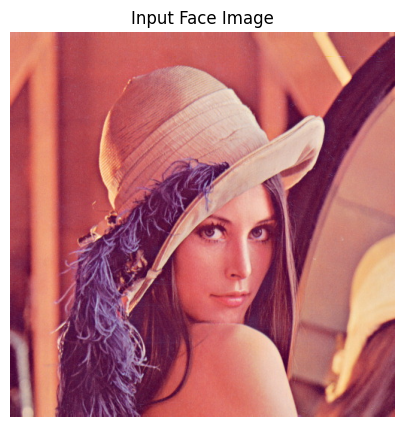

In [2]:

import urllib.request

face_img = None

# Method 1: download a small sample face image
try:
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
    urllib.request.urlretrieve(url, "lena.jpg")
    face_img = cv2.imread("lena.jpg")
    print("Downloaded sample face image.")
except Exception as e:
    print("Download failed:", e)

# Method 2: fallback to skimage astronaut image
if face_img is None:
    try:
        from skimage import data
        astro = data.astronaut()  # RGB
        face_img = cv2.cvtColor(astro, cv2.COLOR_RGB2BGR)
        print("Loaded fallback skimage astronaut image.")
    except Exception as e:
        print("Fallback also failed:", e)

if face_img is None:
    # final fallback: create a simple blank image so the notebook never crashes
    face_img = np.full((400, 400, 3), 230, dtype=np.uint8)
    cv2.putText(face_img, "Upload face image", (35, 200), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)

show_bgr(face_img, "Input Face Image")


## Step 2: Face detection using Haar Cascade
Haar Cascade detects face regions using a pre-trained XML model included with OpenCV.

Faces detected: 1


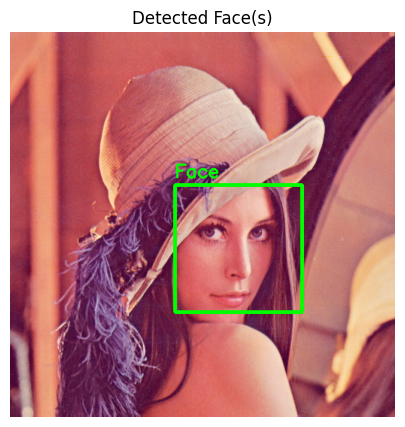

In [3]:

gray_face = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)

cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError("Haar cascade file could not be loaded.")

faces = face_cascade.detectMultiScale(
    gray_face,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40, 40)
)

face_output = face_img.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(face_output, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.putText(face_output, "Face", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

print("Faces detected:", len(faces))
show_bgr(face_output, "Detected Face(s)")


## Step 3: Create an object-detection sample image
We will detect simple objects using contour detection.

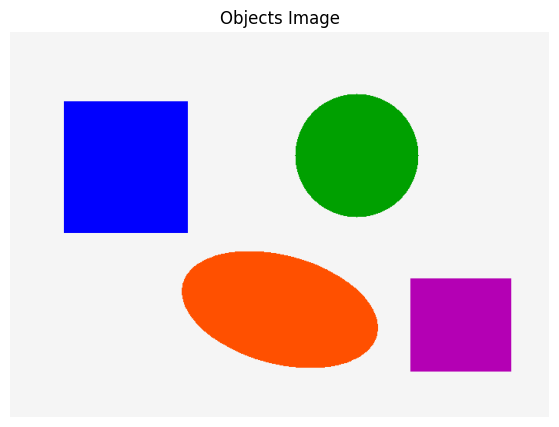

In [4]:

obj_img = np.full((500, 700, 3), 245, dtype=np.uint8)

cv2.rectangle(obj_img, (70, 90), (230, 260), (255, 0, 0), -1)
cv2.circle(obj_img, (450, 160), 80, (0, 160, 0), -1)
cv2.ellipse(obj_img, (350, 360), (130, 70), 15, 0, 360, (0, 80, 255), -1)
cv2.rectangle(obj_img, (520, 320), (650, 440), (180, 0, 180), -1)

show_bgr(obj_img, "Objects Image")


## Step 4: Object detection using contours
After thresholding, contours are found and bounding boxes are drawn around objects.

Objects detected: 4


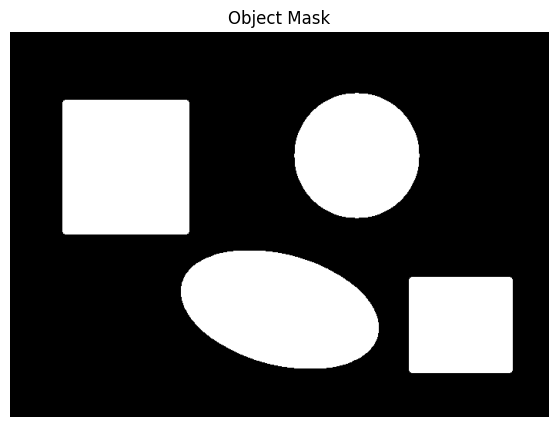

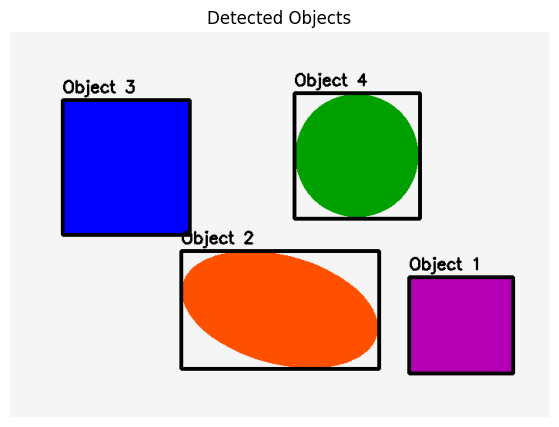

In [5]:

gray_obj = cv2.cvtColor(obj_img, cv2.COLOR_BGR2GRAY)
blur_obj = cv2.GaussianBlur(gray_obj, (5, 5), 0)

# Since background is light, objects are darker/saturated; invert threshold helps isolate them
_, obj_mask = cv2.threshold(blur_obj, 235, 255, cv2.THRESH_BINARY_INV)
obj_mask = cv2.morphologyEx(obj_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

contours, _ = cv2.findContours(obj_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

obj_output = obj_img.copy()
object_count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1000:
        object_count += 1
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(obj_output, (x, y), (x+w, y+h), (0, 0, 0), 3)
        cv2.putText(obj_output, f"Object {object_count}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

print("Objects detected:", object_count)
show_gray(obj_mask, "Object Mask")
show_bgr(obj_output, "Detected Objects")


## Optional: Upload your own image in Colab
Run this cell only if you want to test with your own image.

In [6]:

# Optional upload cell for Google Colab
# Uncomment and run in Colab:
#
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# user_img = cv2.imread(filename)
# show_bgr(user_img, "Uploaded Image")


## Result
The notebook demonstrated face detection using Haar Cascade and object detection using contours.